# Оценка стратегии методами ДП

Для демонстрации методов вычисления V-функции $v_{\pi}(s)$ по выбранной стратегии $\pi$ рассмотрим задачу `FrozenLake` из библиотеки `gymnasium` в упрощённой и исходной постановке.


### Пример 1

Рассмотрим задачу из библиотеки `gymnasium` о замерзшем озере `FrozenLake-v1` с детерминированными переходами. Средой является поле из 16 состояний, разные клетки имеют разное значение. Вид поля:

![Карта FrozenLake](frozen.png)

Здесь:

    S (Start)  начало
    F (Frozen) участок со льдом, где можно идти
    H (Hole)   прорубь, надо избегать
    G (Goal)   цель.
    
Действия - это перемещения по полю в 4 направления: 

    0: влево
    1: вниз
    2: вправо
    3: вверх

Состояния - это клетки поля, где может находится агент. Они нумеруются числами от 0 до 15.

**Цель:** добраться из клетки `S` до клетки `G`. Вознаграждение за успешное завершение эпизода +1. За все прочие действия 0.

Эпизод **завершается** 
- при успешном переходе из `S` в `G` по `F` клеткам,
- при попадании на клетку `H`,
- по истечении 100 временных шагов.
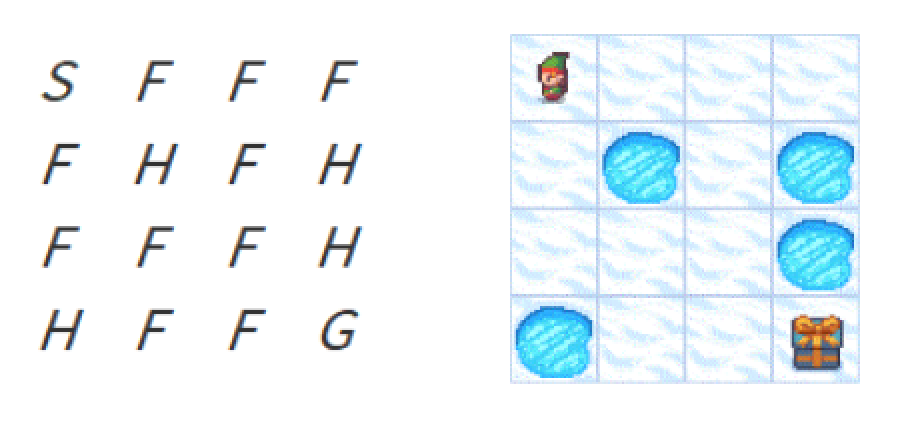

Ключевым элементом дискретных сред, имеющих **полное описание динамики среды**, является набор данных `env.P`, который представляется обычно как словарь словарей. У внешнего словаря ключами являются состояния $s$, а значениями `env.P[s]` будут словари, в которых ключи - это действия $a$, значения внутреннего словаря `env.P[s][a]`, хранят список, каждый элемент которого представляет собой кортеж (или tuple) из 4-х значений вида

$(p(s',r|s,a), s', r, terminated),$

то есть вероятность перехода в состояние $s'$ с вознаграждением $r$, состояние $s'$, вознаграждение $r$ и флаг $terminated$ о том, является ли состояние заключительным.

При создании среды `FrozenLake-v1` в параметрах метода `gym.make()` укажем параметр `is_slippery = False`, чтобы переходы между состояниями были детерминированы, то есть, например, действие влево действительно перенесёт нас на клетку левее (кроме случая, когда слева уже конец поля, в этом случае агент остаётся на месте). По умолчанию в этой среде переходы стохастичны, этот случай разобран чуть ниже.

In [3]:
import gymnasium as gym
import numpy as np

#создание экземпляра среды, обёртка unwrapped для доступа к матрице переходов env.P
env = gym.make("FrozenLake-v1", is_slippery = False).unwrapped 

Создадим экземпляр среды в переменной `env`. Для инициализации среды можно использовать метод `env.reset()`

In [28]:
state, _ = env.reset()
print(state)

0


Продемонстрируем взаимодействие агента со средой (появляется в отдельном окошке, если `render_mode='human'`)

In [50]:
import time

env = gym.make("FrozenLake-v1", render_mode='human', is_slippery = False)
env.reset()

while True:
    time.sleep(.2)
    state, reward, terminated, truncated, _ = env.step(env.action_space.sample()) # выбрать действие случайно
    if terminated or truncated:
        break
    
env.close()

Для упрощённого способа демонстрации взаимодействия агента со средой можно использовать следующий код (для этого надо поставить параметр `render_mode='ansi'`).

In [2]:
import time
from IPython.display import clear_output

env = gym.make("FrozenLake-v1", render_mode='ansi', is_slippery = False)
env.reset()
print(env.render())

while True:    
    state, reward, terminated, truncated, _ = env.step(env.action_space.sample()) # выбрать действие случайно
    
    time.sleep(.2)
    clear_output(wait=True)      
    print(env.render())
    
    if terminated or truncated:
        break
    
env.close()

  (Right)
SFFF
FHFH
FFFH
HFFG



In [3]:
# проверка работы на разных действиях из стартового состояния
for action in range(4):
    env.reset()
    new_state, _, _, _, _ = env.step(action)
    print(new_state)

0
4
1
0


Посмотрим информацию из набора данных `env.P` о динамике среды.

In [6]:
# вывод динамики переходов
env.unwrapped.P[0]

{0: [(1.0, 0, 0, False)],
 1: [(1.0, 4, 0, False)],
 2: [(1.0, 1, 0, False)],
 3: [(1.0, 0, 0, False)]}

Пусть агент действует по некоторой стратегии $\pi$. В каждом из состояний возможно одно из 4-х действий. Будем обозначать действия влево, вниз, вправо, вверх за  $a_1,a_2,a_3,a_4$, соответственно. Значит, для каждого состояния $s$ надо задать список из четырёх чисел 
$$[\pi(a_1|s),\pi(a_2|s),\pi(a_3|s),\pi(a_4|s)],$$
означающих вероятность выбора того или иного действия в состоянии $s$.

Программно стратегию будем задавать в виде массива чисел `policy` размера 16 на 4.

Вычисление V-функции для выбранной стратегии реализуем в виде двух отдельных функций: **по итеративному методу** и **точному методу**. 

Итеративный метод реализуем с **in-place** вычислениями.

#### Итеративный метод

Итеративная формула обновления оценки ценности состояния $s$ имеет вид

$V(s) \leftarrow \sum\limits_{a\in {\mathcal A}} \pi(a|s)  
\sum\limits_{s'\in {\mathcal S}}
\sum\limits_{r\in {\mathcal R}}
p(s',r|s,a) (r + \gamma V(s')), \quad s\in {\mathcal S},$

где 
$V(s)$ оценка ценности состояния $s$, 
$p(s',r|s,a)$ вероятность перехода из состояния $s$ при действии $a$ в состояние $s'$ с вознаграждением $r$. 

Критерием остановки итераций будет малость изменения вектора `V` по `max`-норме.

In [7]:
def PolicyEvaluation(env, policy, gamma, theta=1e-5):
    nS = env.observation_space.n # количество различных состояний    
    V = np.zeros(nS)             # начальная оценка ценностей состояний
    error = []       # массив для хранения ошибки
    while True:
        delta = 0
        # Вычисление новых оценок для всех состояний
        for state in range(nS):         
            v_s_old = V[state] # запоминаем значение v(s), для его сравнения с обновлённым значением v(s)
            v_s = 0 # для вычисления обновлённого значения v(s)        
            act_probs = policy[state]
            for act, act_prob in enumerate(act_probs):
                for next_sr in env.P[state][act]:
                    trans_prob, new_state, reward, _ = next_sr
                    v_s += act_prob * trans_prob * (reward + gamma * V[new_state])
            V[state] = v_s
            # найдём разницу между старым и новым значением v(s)
            delta = np.max([delta, np.abs(V[state] - v_s_old)])
        # Критерий завершения итераций
        error.append(delta)
        if delta < theta:
            break
    return V, error

#### Задача: реализовать точный метод

Надо сформировать матрицу $I-\gamma P$ и столбец $R$. Здесь $I$ - единичная матрица, $P = \{P^{\pi}(s'|s)\}$ матрица вероятностей перехода из состояния $s$ в состояние $s'$, столбец $R = \{R^{\pi}(s)\}$ состоит из ожидаемых вознаграждений за переход из состояний $s \in {\mathcal S}$:

In [8]:
def PolicyEvaluationExact(env, policy, gamma):
# нахождение точных значений функции ценности из решения СЛАУ
    ...
    ...
    ...
    
    return V

Предположим, что агент следует стратегии, где все действия выбрираются **равновероятно**. Вычислим функцию ценности состояний $v_\pi(s)$ при такой стратегии и при $\gamma = 0.9.$
Выведем также график убывания ошибки.

[[0.012 0.01  0.019 0.009]
 [0.015 0.    0.039 0.   ]
 [0.033 0.084 0.138 0.   ]
 [0.    0.17  0.434 0.   ]]


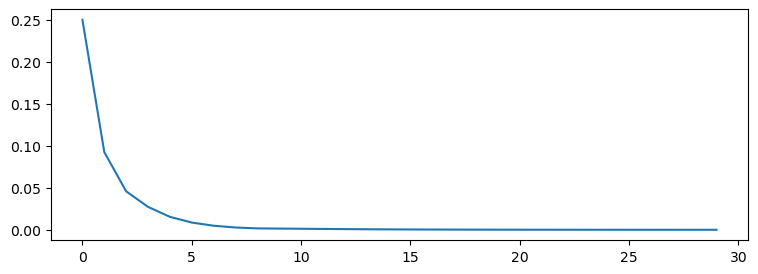

In [9]:
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery = False).unwrapped 
gamma = 0.99
policy = np.zeros((env.observation_space.n, env.action_space.n)) + 1/4

# итеративное вычисление функции ценности 
new_value, error = PolicyEvaluation(env, policy, gamma)
print(np.round(new_value,3).reshape(4,4))
plt.figure(figsize=(9,3))
plt.plot(error)

In [10]:
# точное вычисление функции ценности 
gamma = 0.99
np.round(PolicyEvaluationExact(env, policy, gamma),3).reshape(4,4)

array([[ 0.012,  0.01 ,  0.019,  0.009],
       [ 0.015, -0.   ,  0.039, -0.   ],
       [ 0.033,  0.084,  0.138,  0.   ],
       [ 0.   ,  0.17 ,  0.434,  0.   ]])

Поскольку задача эпизодическая, то можно положить $\gamma = 1$. Тогда ценности состояний будут означать среднее число шагов из этого состояния до заключительного состояния с обратным знаком. В силу выбранной системы вознаграждений, максимизация дохода предполагает как можно более быстрое движение в заключительные состояния из клеток сеточного мира.

In [11]:
gamma = 1.0
policy = np.zeros((env.observation_space.n, env.action_space.n)) + 1/4

# итеративное вычисление функции ценности 
new_value, _ = PolicyEvaluation(env, policy, gamma)
print(np.round(new_value,3).reshape(4,4))

[[0.014 0.012 0.021 0.01 ]
 [0.016 0.    0.041 0.   ]
 [0.035 0.088 0.142 0.   ]
 [0.    0.176 0.439 0.   ]]


### Сравнения разных способов организации вычислений

Сравним два варианта организации вычислений: с полным обновлением и обновлением **in-place**.

Для этого модифицируем метод `PolicyEvaluation()`, чтобы он выдавал число итераций для сходимости.

Для наглядности также изменим порядок прохода по состояниям: от последнего по индексу к началу. 

In [65]:
def PolicyEvaluation(env, policy, gamma, theta=1e-5):
    nS = env.observation_space.n # количество различных состояний    
    V = np.zeros(nS)             # начальная оценка ценностей состояний
    iteration = 0
    while True:
        delta = 0
        # Вычисление новых оценок для всех состояний
        for state in reversed(range(nS)):         
            v_s_old = V[state] # запоминаем значение v(s), для его сравнения с обновлённым значением v(s)
            v_s = 0 # для вычисления обновлённого значения v(s)        
            act_probs = policy[state]
            for act, act_prob in enumerate(act_probs):
                for next_sr in env.P[state][act]:
                    trans_prob, new_state, reward, _ = next_sr
                    v_s += act_prob * trans_prob * (reward + gamma * V[new_state])
            V[state] = v_s
            # найдём разницу между старым и новым значением v(s)
            delta = np.max([delta, np.abs(V[state] - v_s_old)])
        iteration = iteration + 1
        # Критерий завершения итераций
        if delta < theta:
            break
        if iteration > 2000:
            print("Более 2000 итераций. Стоп.")
            return V
        # демонстрация динамики обучения
        if iteration == 1 or iteration == 2 or iteration == 5 or iteration == 10 or iteration == 50:
            print("Итерация: ", iteration)
            print(V.reshape(4,4)) 
    print("Число итераций: ", iteration)
    return V

In [66]:
def PolicyEvaluation_FullUpdate(env, policy, gamma, theta=1e-5):
    nS = env.observation_space.n # количество различных состояний    
    V = np.zeros(nS)             # начальная оценка ценностей состояний
    iteration = 0
    while True:
        delta = 0
        # Вычисление новых оценок для всех состояний
        old_V = V.copy() # создаём копию массива
        for state in reversed(range(nS)):         
            v_s = 0 # для вычисления обновлённого значения v(s)        
            act_probs = policy[state]
            for act, act_prob in enumerate(act_probs):
                for next_sr in env.P[state][act]:
                    trans_prob, new_state, reward, _ = next_sr
                    v_s += act_prob * trans_prob * (reward + gamma * old_V[new_state])
            V[state] = v_s
            # найдём разницу между старым и новым значением v(s)
            delta = np.max([delta, np.abs(V[state] - old_V[state])])
        iteration = iteration + 1
        # Критерий завершения итераций
        if delta < theta:
            break
        if iteration > 2000:
            print("Более 2000 итераций. Стоп.")
            return V
        # демонстрация динамики обучения
        if iteration == 1 or iteration == 2 or iteration == 5 or iteration == 10 or iteration == 50:
            print("Итерация: ", iteration)
            print(V.reshape(4,4)) 
    print("Число итераций: ", iteration)
    return V

Проведём сравнений вычислений.

In [70]:
env = gym.make("FrozenLake-v1", is_slippery = False).unwrapped 
policy = np.zeros((env.observation_space.n, env.action_space.n)) + 1/4

new_value = PolicyEvaluation(env, policy, gamma=1.0)
print(np.round(new_value,3).reshape(4,4))

Итерация:  1
[[0.00073242 0.00097656 0.00390625 0.        ]
 [0.00195312 0.         0.015625   0.        ]
 [0.0078125  0.03125    0.0625     0.        ]
 [0.         0.0625     0.25       0.        ]]
Итерация:  2
[[0.00212097 0.00238037 0.0078125  0.00097656]
 [0.00463867 0.         0.02539062 0.        ]
 [0.01586914 0.05371094 0.09765625 0.        ]
 [0.         0.109375   0.34375    0.        ]]
Итерация:  5
[[0.00714574 0.0064871  0.01513958 0.0053103 ]
 [0.01098531 0.         0.03666496 0.        ]
 [0.02906692 0.0806911  0.13333035 0.        ]
 [0.         0.16317654 0.42294312 0.        ]]
Итерация:  10
[[0.01192878 0.01011066 0.01943223 0.00905202]
 [0.01491976 0.         0.04004284 0.        ]
 [0.03383348 0.08736975 0.14120536 0.        ]
 [0.         0.17481267 0.43806991 0.        ]]
Число итераций:  26
[[0.014 0.012 0.021 0.01 ]
 [0.016 0.    0.041 0.   ]
 [0.035 0.088 0.142 0.   ]
 [0.    0.176 0.439 0.   ]]


In [71]:
new_value = PolicyEvaluation_FullUpdate(env, policy, gamma=1.0)
print(np.round(new_value,3).reshape(4,4))

Итерация:  1
[[0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.25 0.  ]]
Итерация:  2
[[0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.0625 0.    ]
 [0.     0.0625 0.3125 0.    ]]
Итерация:  5
[[0.         0.00097656 0.00585938 0.00097656]
 [0.00195312 0.         0.02636719 0.        ]
 [0.01269531 0.05761719 0.11132812 0.        ]
 [0.         0.13671875 0.40136719 0.        ]]
Итерация:  10
[[0.005476   0.00562477 0.01481819 0.00595379]
 [0.0100193  0.         0.03692722 0.        ]
 [0.02887154 0.08184433 0.13635063 0.        ]
 [0.         0.16892052 0.43254757 0.        ]]
Число итераций:  39
[[0.014 0.012 0.021 0.01 ]
 [0.016 0.    0.041 0.   ]
 [0.035 0.088 0.142 0.   ]
 [0.    0.176 0.439 0.   ]]


Как ясно из полученных результатов, при вычислениях **in-place** число итераций для сходимости требуется меньше по той причине, что обновлённое значение становится сразу доступно для обновления значения в следующем состоянии.

### Итоговый код для метода оценки стратегии

Приведём итоговый код для оценки стратегии, вычисляющий функцию ценности состояний при фиксированной стратегии.

In [76]:
def PolicyEvaluation(env, policy, gamma, theta=1e-5):
    nS = env.observation_space.n # количество различных состояний    
    V = np.zeros(nS)             # начальная оценка ценностей состояний
    iteration = 0
    while True:
        delta = 0
        # Вычисление новых оценок для всех состояний
        for state in range(nS):         
            v_s_old = V[state] # запоминаем значение v(s), для его сравнения с обновлённым значением v(s)
            v_s = 0 # для вычисления обновлённого значения v(s)        
            act_probs = policy[state]
            for act, act_prob in enumerate(act_probs):
                for next_sr in env.P[state][act]:
                    trans_prob, new_state, reward, _ = next_sr
                    v_s += act_prob * trans_prob * (reward + gamma * V[new_state])
            V[state] = v_s
            # найдём разницу между старым и новым значением v(s)
            delta = np.max([delta, np.abs(V[state] - v_s_old)])
        iteration = iteration + 1
        # Критерий завершения итераций
        if delta < theta:
            break
        if iteration > 2000:
            print("Более 2000 итераций. Стоп.")
            return V
    print("Число итераций: ", iteration)
    return V

In [62]:
env = gym.make("FrozenLake-v1", is_slippery = False).unwrapped 

gamma = 1.0
policy = np.zeros((env.observation_space.n, env.action_space.n)) + 1/4


# итеративное вычисление функции ценности 
V = PolicyEvaluation(env, policy, gamma)

Число итераций:  31


In [63]:
print(np.round(V,3).reshape(4,4))

[[0.014 0.012 0.021 0.01 ]
 [0.016 0.    0.041 0.   ]
 [0.035 0.088 0.142 0.   ]
 [0.    0.176 0.439 0.   ]]


### Пример 2

По умолчанию в задаче о замерзшем озере `FrozenLake-v1` переходы между состояниями стохастичны, что как бы моделирует хождение по льду. 

Из-за скольского льда есть вероятность перехода не в том направлении. Например, при действии "вниз" с вероятностью 1/3 агент переместится либо вниз, либо влево, либо вправо (причём если перемещение за край поля, то агент останется на месте). 

Цель та же: добраться из клетки `S` до клетки `G`.

In [72]:
import gymnasium as gym
import numpy as np

#создание экземпляра среды, обёртка unwrapped для доступа к матрице переходов env.P
env = gym.make("FrozenLake-v1").unwrapped 
env.reset() # инициализация среды
# вывод динамики переходов
env.P

{0: {0: [(0.33333333333333337, 0, 0, False),
   (0.3333333333333333, 0, 0, False),
   (0.33333333333333337, 4, 0, False)],
  1: [(0.33333333333333337, 0, 0, False),
   (0.3333333333333333, 4, 0, False),
   (0.33333333333333337, 1, 0, False)],
  2: [(0.33333333333333337, 4, 0, False),
   (0.3333333333333333, 1, 0, False),
   (0.33333333333333337, 0, 0, False)],
  3: [(0.33333333333333337, 1, 0, False),
   (0.3333333333333333, 0, 0, False),
   (0.33333333333333337, 0, 0, False)]},
 1: {0: [(0.33333333333333337, 1, 0, False),
   (0.3333333333333333, 0, 0, False),
   (0.33333333333333337, 5, 0, True)],
  1: [(0.33333333333333337, 0, 0, False),
   (0.3333333333333333, 5, 0, True),
   (0.33333333333333337, 2, 0, False)],
  2: [(0.33333333333333337, 5, 0, True),
   (0.3333333333333333, 2, 0, False),
   (0.33333333333333337, 1, 0, False)],
  3: [(0.33333333333333337, 2, 0, False),
   (0.3333333333333333, 1, 0, False),
   (0.33333333333333337, 0, 0, False)]},
 2: {0: [(0.33333333333333337, 2, 0

In [73]:
env.step(0)

(4, 0, False, False, {'prob': 0.33333333333333337})

Например, ниже выведены вероятности перехода из состояния 1 и действия 1:

In [74]:
env.P[1][1]

[(0.33333333333333337, 0, 0, False),
 (0.3333333333333333, 5, 0, True),
 (0.33333333333333337, 2, 0, False)]

Найдём функцию ценности состояний для стратегии с равновероятным выбором действий

In [79]:
env = gym.make("FrozenLake-v1", render_mode='ansi').unwrapped 
# стратегия равновероятного выбора
gamma = 1.0
# число состояний и действий
nS = env.observation_space.n
nA = env.action_space.n

policy = np.zeros([nS, nA]) + 1/4
V = PolicyEvaluation(env, policy, gamma)
print(V.reshape(4,4))

Число итераций:  31
[[0.013911   0.01161424 0.02094062 0.01046758]
 [0.01623478 0.         0.04074774 0.        ]
 [0.03479961 0.08816698 0.14205099 0.        ]
 [0.         0.17581855 0.4392897  0.        ]]


Проведём симуляцию на большом числе эпизодов и найдём число успешных завершений среды при случайной стратегии.

In [80]:
n_episodes = 10000
env = gym.make("FrozenLake-v1", render_mode='ansi')
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

def play(env, n_episodes):
    for episode in range(n_episodes):
        state, _ = env.reset()
        while True:
            # равновероятно выбираем действия
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                break
            
play(env, n_episodes)
print("Число успешных завершений эпизода: ", sum(env.return_queue))

Число успешных завершений эпизода:  141.0


### Визуализация обновлений значений V-функции

#### Код для визуализации

In [1]:
import matplotlib.pyplot as plt

# Получение оптимальных действий по оптимальной функции ценности состояний
def GetOptimalActionsByPolicy(optPolicy):
    nS = len(optPolicy)
    # пустой список из нулей для записи оптимальных действий
    bestActs = [0]*nS
    for state in range(nS):
        bestActs[state] = np.argwhere(optPolicy[state] == np.max(optPolicy[state])).flatten().tolist()
    return bestActs


def plot_policy_over_render(policies, title="Оптимальные действия"):
    # Получаем текущее изображение (среда должна быть в режиме rgb_array)
    env_tmp = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True, render_mode='rgb_array')
    # Выполните сброс, чтобы получить первый кадр
    obs, _ = env_tmp.reset()
    img = env_tmp.render().copy()   # numpy array (height, width, 3)
    env_tmp.close()
    fig, ax = plt.subplots(figsize=(6, 6))
    # Отображаем изображение
    ax.imshow(img)
    
    # Размеры изображения и клетки
    h, w, _ = img.shape
    cell_h = h / 4
    cell_w = w / 4
    
    # Сетка (опционально, чтобы видеть границы)
    for i in range(1, 4):
        ax.axhline(i * cell_h, color='black', linewidth=1, linestyle='-')
        ax.axvline(i * cell_w, color='black', linewidth=1, linestyle='-')
    
    # Направления действий: 0-влево, 1-вниз, 2-вправо, 3-вверх
    dirs = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}
    
    for i in range(4):
        for j in range(4):
            state = i * 4 + j
            # Пропускаем особые состояния (дырки, цель) – можно не рисовать стрелки
            if state in [5, 7, 11, 12]:  # H
                continue
            if state == 15:              # G (цель)
                continue
            acts = policies[state]
            if not acts:
                continue
            # Координаты центра клетки (в пикселях)
            cx = j * cell_w + cell_w / 2
            cy = i * cell_h + cell_h / 2
            n = len(acts)
            # Длина стрелки – ~40% размера клетки
            length = min(cell_w, cell_h) * 0.4
            if n == 1:
                dy, dx = dirs[acts[0]]

                ax.arrow(cx, cy, dx * length, dy * length,
                         head_width=min(cell_w, cell_h)*0.15,
                         head_length=min(cell_w, cell_h)*0.15,
                         fc='black', ec='black', width=min(cell_w, cell_h)*0.04,
                         length_includes_head=True)
            else:
                # Для нескольких стрелок можно слегка сместить или использовать разные цвета
                # Но здесь для простоты рисуем все из центра (будут перекрываться)
                offset = min(cell_w, cell_h) * 0.08
                for k, a in enumerate(acts):
                    dy, dx = dirs[a]
                    # Смещение перпендикулярно направлению для визуального разделения
                    # (упрощённо – просто небольшое смещение в случайную сторону)
                    # Для красоты лучше разнести по кругу, но для краткости сделаем просто все из центра
                    ax.arrow(cx, cy, dx * length, dy * length,
                             head_width=min(cell_w, cell_h)*0.12,
                             head_length=min(cell_w, cell_h)*0.12,
                             fc='black', ec='black', width=min(cell_w, cell_h)*0.03,
                             length_includes_head=True, alpha=0.9)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

from ipywidgets import IntSlider, interactive, Layout
import IPython.display as display


def PolicyEvaluation_history(env, policy, gamma=0.99, theta=1e-5, return_history=False):
    nS = env.observation_space.n
    V = np.zeros(nS)
    history = [V.copy()]  # сохраняем начальное состояние
    iteration = 0
    while True:
        delta = 0
        V_new = V.copy()
        for state in range(nS):
            v_s = 0
            act_probs = policy[state]
            for act, act_prob in enumerate(act_probs):
                if act_prob == 0:
                    continue
                for trans_prob, new_state, reward, _ in env.P[state][act]:
                    v_s += act_prob * trans_prob * (reward + gamma * V[new_state])
            V_new[state] = v_s
            delta = max(delta, abs(V_new[state] - V[state]))
        V = V_new
        iteration += 1
        if return_history:
            history.append(V.copy())
        if delta < theta:
            break
        if iteration > 2000:
            print("Превышен лимит итераций (2000). Остановка.")
            break
    print(f"Оценка завершена за {iteration} итераций.")
    if return_history:
        return V, history
    else:
        return V

        
# Функция обновления графика
def show_V(iteration):
    V = history[iteration]
    grid = V.reshape(4, 4)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(grid, cmap='Greens', vmin=0, vmax=1.0)
    ax.set_title(f'V-функция на итерации {iteration}')
    
    # === СЕТКА ===
    ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
    # ==============
    
    # Подписи значений
    for i in range(4):
        for j in range(4):
            state = i*4 + j
            if state ==  15:
                ax.text(j, i, 'T', ha='center', va='center', color='black', fontsize=14, weight='bold')
                continue
            if state == 5 or state == 7 or state ==  11 or state ==  12 or state ==  15:
                ax.text(j, i, 'H', ha='center', va='center', color='black', fontsize=14, weight='bold')
                continue
            val = grid[i, j]
            text = f'{val:.2f}' if abs(val) > 0.01 else f'{val:.3f}'
            ax.text(j, i, text, ha='center', va='center', 
                    color='black' if val < 0.5 else 'white')
    
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

#### Детерминированные переходы: эволюция V при gamma = 1.0

In [2]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery = False).unwrapped 
env.reset() # инициализация среды

# выведем описания пространств состояний и действий
print("Пространство состояний:", env.observation_space)
print("Пространство действий:", env.action_space)

Пространство состояний: Discrete(16)
Пространство действий: Discrete(4)


Рассмотрим некоторую детерминированную стратегию.

D:\anaconda3\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


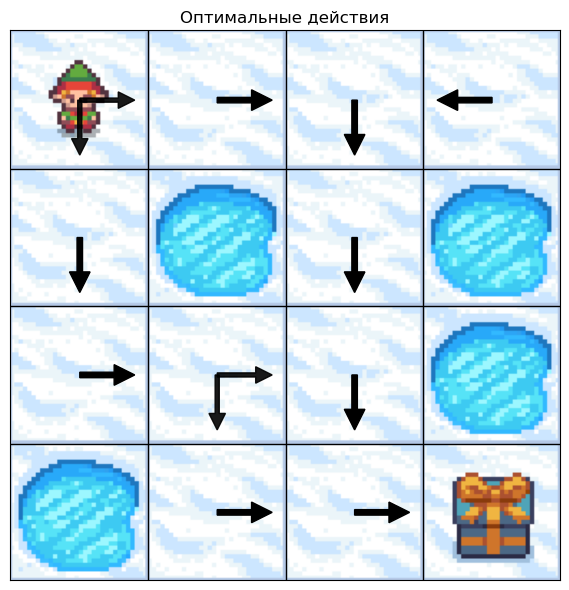

In [3]:
optPolicy = np.array([
    [0.0, 0.5, 0.5, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.5, 0.5, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.25, 0.25, 0.25, 0.25]
])

optActs = GetOptimalActionsByPolicy(optPolicy)

plot_policy_over_render(optActs)

Найдём V-функцию для этой стратегии и визуализируем эволюцию значений V-функции.

In [4]:
# Запускаем оценку с сохранением истории
V_final, history = PolicyEvaluation_history(env, optPolicy, gamma=1.0, theta=1e-5, return_history=True)
print(f"Количество сохранённых шагов: {len(history)}")

Оценка завершена за 7 итераций.
Количество сохранённых шагов: 8


In [5]:
# Создаём слайдер
slider = IntSlider(
    value=0,
    min=0,
    max=len(history)-1,
    step=1,
    description='Итерация:',
    layout=Layout(width='600px')
)

# Интерактивный виджет
interactive(show_V, iteration=slider)

interactive(children=(IntSlider(value=0, description='Итерация:', layout=Layout(width='600px'), max=7), Output…

#### Детерминированные переходы: эволюция V при gamma = 0.9

Та же стратегия, что и выше, но `gamma=0.9`.

In [6]:
# Запускаем оценку с сохранением истории
V_final, history = PolicyEvaluation_history(env, optPolicy, gamma=0.9, theta=1e-5, return_history=True)
print(f"Количество сохранённых шагов: {len(history)}")

Оценка завершена за 7 итераций.
Количество сохранённых шагов: 8


In [7]:
# Создаём слайдер
slider = IntSlider(
    value=0,
    min=0,
    max=len(history)-1,
    step=1,
    description='Итерация:',
    layout=Layout(width='600px')
)

# Интерактивный виджет
interactive(show_V, iteration=slider)

interactive(children=(IntSlider(value=0, description='Итерация:', layout=Layout(width='600px'), max=7), Output…

#### Стохастические переходы: эволюция V при gamma = 1.0

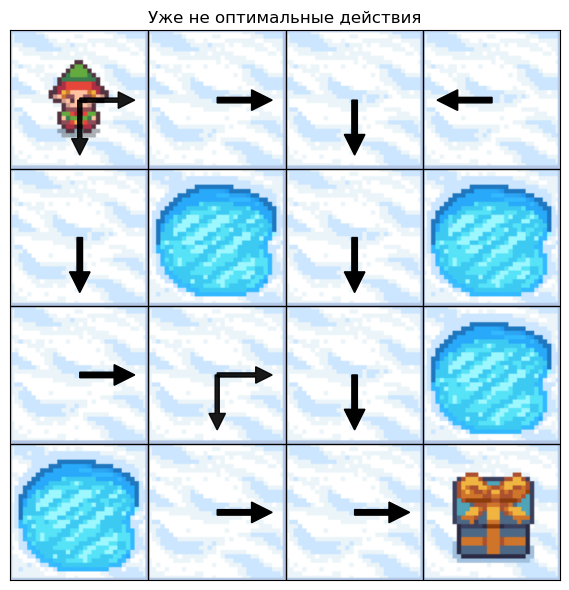

In [9]:
env = gym.make("FrozenLake-v1",).unwrapped 

somePolicy = np.array([
    [0.0, 0.5, 0.5, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.5, 0.5, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.25, 0.25, 0.25, 0.25],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.25, 0.25, 0.25, 0.25]
])

someActs = GetOptimalActionsByPolicy(somePolicy)

plot_policy_over_render(someActs, title="Уже не оптимальные действия")

In [10]:
# Запускаем оценку с сохранением истории
V_final, history = PolicyEvaluation_history(env, somePolicy, gamma=1.0, theta=1e-3, return_history=True)
print(f"Количество сохранённых шагов: {len(history)}")

Оценка завершена за 19 итераций.
Количество сохранённых шагов: 20


In [11]:
# Создаём слайдер
slider = IntSlider(
    value=0,
    min=0,
    max=len(history)-1,
    step=1,
    description='Итерация:',
    layout=Layout(width='600px')
)

# Интерактивный виджет
interactive(show_V, iteration=slider)

interactive(children=(IntSlider(value=0, description='Итерация:', layout=Layout(width='600px'), max=19), Outpu…

Оптимальная стратегия для детерминированного случая оказалась немногим лучше случайной стратегии для той же среды с зашумлёнными действиями.

В следующем файле найдём оптимальную стратегию для задачи о замёрзшем озере `FrozenLake`.

**Вопрос:** если бы агент нашел бы оптимальную стратегию, то какими должно быть лучшее действие в клекте  с индексом 6?

![Карта FrozenLake](frozen.png)